## what is the simplest equation of a straight line?
- y=mx+c



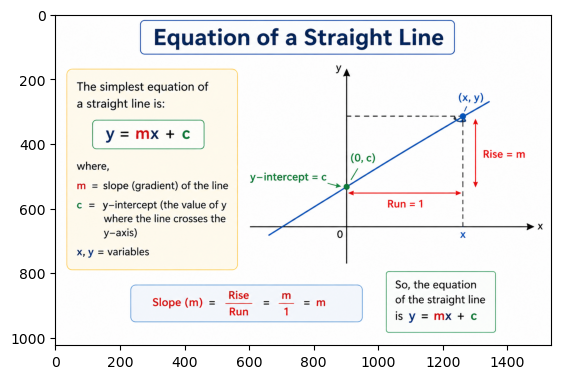

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Load image
img = mpimg.imread("/Users/gajendra06/Downloads/a_clean_educational_infographic_slide_style_image.png")

# Display image
plt.imshow(img)
# plt.axis("off")   # Hide axes
plt.show()

In [3]:
import numpy as np
import pandas as pd
import scipy 
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
import sklearn
from sklearn.model_selection import train_test_split


In [4]:
df = pd.read_excel('CDAC_DataBook.xlsx', sheet_name='faithful')

In [5]:
df.head()

,eruptions,waiting
0,3.600,79
1,1.800,54
2,3.333,74
3,2.283,62
4,4.533,85


In [6]:
scipy.stats.pearsonr(df.eruptions, df.waiting)

PearsonRResult(statistic=np.float64(0.9008111683218131), pvalue=np.float64(8.129958506617982e-100))

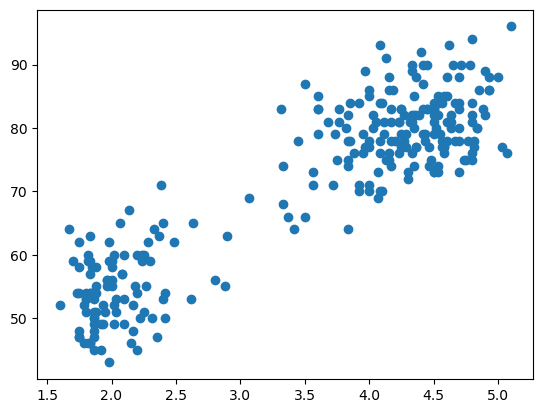

In [7]:
plt.scatter(df.eruptions, df.waiting)

In [8]:
x_train, x_test,y_train, y_test = train_test_split(df.waiting, df.eruptions, test_size=0.3)

In [9]:
x_train, x_test,y_train, y_test

(89     86
 218    55
 271    74
 26     55
 144    76
        ..
 6      88
 143    77
 206    77
 264    43
 122    77
 Name: waiting, Length: 190, dtype: int64,
 170    49
 142    82
 145    59
 76     60
 233    50
        ..
 253    73
 97     75
 167    88
 16     62
 115    81
 Name: waiting, Length: 82, dtype: int64,
 89     4.000
 218    2.000
 271    4.467
 26     1.967
 144    4.333
        ...  
 6      4.700
 143    4.817
 206    4.367
 264    1.983
 122    4.250
 Name: eruptions, Length: 190, dtype: float64,
 170    1.917
 142    4.533
 145    1.983
 76     2.017
 233    2.217
        ...  
 253    4.500
 97     3.750
 167    5.000
 16     1.750
 115    4.633
 Name: eruptions, Length: 82, dtype: float64)

In [10]:
x_train.head

<bound method NDFrame.head of 89     86
218    55
271    74
26     55
144    76
       ..
6      88
143    77
206    77
264    43
122    77
Name: waiting, Length: 190, dtype: int64>

In [11]:
x_train.shape

(190,)

In [12]:
# Split for train_test

x_train, x_test,y_train, y_test = train_test_split(df.waiting, df.eruptions, test_size=0.3, random_state=20)

### Adding Constant term

In [13]:
x_train = sm.add_constant(x_train, prepend=False)

In [14]:
x_test = sm.add_constant(x_test, prepend=False)

In [15]:
x_train

,waiting,const
182,83,1.0
248,67,1.0
50,75,1.0
209,83,1.0
200,60,1.0
...,...,...
162,58,1.0
71,56,1.0
218,55,1.0
223,75,1.0


In [16]:
x_test

,waiting,const
72,79,1.0
132,56,1.0
129,90,1.0
29,79,1.0
87,80,1.0
...,...,...
207,84,1.0
73,71,1.0
102,49,1.0
245,82,1.0


In [17]:
x_train + x_test

,waiting,const
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN
...,...,...
267,NaN,NaN
268,NaN,NaN
269,NaN,NaN
270,NaN,NaN


In [18]:
# Creating the model 
mod1 = sm.OLS(y_train,x_train).fit()

In [19]:
print(mod1.summary())

                            OLS Regression Results                            
Dep. Variable:              eruptions   R-squared:                       0.804
Model:                            OLS   Adj. R-squared:                  0.803
Method:                 Least Squares   F-statistic:                     771.1
Date:                Thu, 04 Jun 2026   Prob (F-statistic):           1.94e-68
Time:                        09:31:50   Log-Likelihood:                -140.85
No. Observations:                 190   AIC:                             285.7
Df Residuals:                     188   BIC:                             292.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
waiting        0.0782      0.003     27.768      0.0

# coef : waiting = 0.0782 becoming m

- eruption = 0.0782 x waiting - 2.08
  - -  R-square (coef of determinatoin) : - it signifies/represent the percentage of variance in the data explain by the model. [0.804] = 80.4% variation
    -  P>|t| :- It shows the P-value (0.000)
    -  Last 2 Columns [0.025    o.975] : Internal Estimate
    -  Steps
       1. null hypothesis : m =0
       2. P-value : 0
       3. null Hypothesis (reject)
       4. Either m is not equal to 0 / Waiting is eruption
       5. what's the effect if 1 increase then waiting will increase by [0.0782]


-         between          Explained 
- f = --------------. . . . . . . .= ---------------
-         With in          Unexplained

##### total = Explained + Unexplained

#### basics of this must know how.......

m \
c \
R-square

In [20]:
# 0.0782 / 0.003
-2.0814 / 0.203

-10.25320197044335

In [21]:
mydata = pd.DataFrame([[80,1],[90,1],[100,1]], columns = x_train.columns)
mypreds = mod1.predict(mydata)
y_preds = mod1.predict(x_train)

In [22]:
y_preds.head()

182    4.411512
248    3.159859
50     3.785686
209    4.411512
200    2.612262
dtype: float64

In [23]:
y_train.head()

182    4.250
248    2.133
50     4.800
209    4.500
200    2.100
Name: eruptions, dtype: float64

This both are Error = Residual Error (in regression)

In [24]:
residuals = y_train - y_preds

(array([ 5.,  9., 18., 30., 25., 36., 30., 20., 13.,  4.]),
 array([-1.25817472, -1.01204863, -0.76592254, -0.51979646, -0.27367037,
        -0.02754428,  0.21858181,  0.4647079 ,  0.71083398,  0.95696007,
         1.20308616]),
 <BarContainer object of 10 artists>)

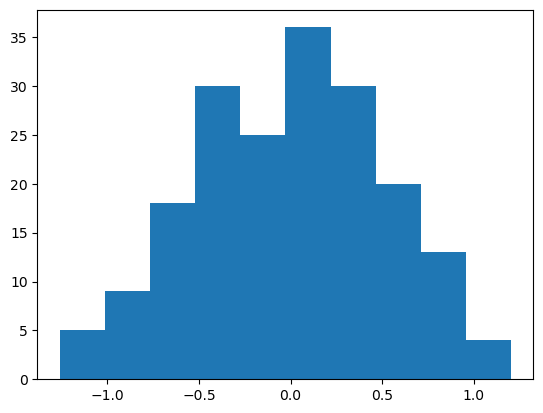

In [25]:
plt.hist(residuals)

 - SSE (Sum Square of Error) \
SSE  = Unexplained variation



In [26]:
SSE = sum(residuals**2) 

In [27]:
SSE

48.996794571239164

- SST = (Sum square of total variation)

In [28]:
SST = sum((y_train - np.mean(y_train))**2)

In [29]:
SST


249.95112065263157

In [30]:
SSR = SST - SSE # sun Square regression OR Explained Variation

In [31]:
SSR

200.95432608139242

In [32]:
SSR/SST

0.8039744953200981

Number of Values = 190 \
Total  Degree of Freedom (DoF) = 189  
DoF for regression model =  2-1 = 1 \
DoF for error or residual = 189 - 1 = 188 



R-Square is always done using [Training set] model.



Coefficent of waiting [0.0782] is the increase in the response when the predictor waiting is increase by 1 unit

# Sklearn


In [33]:
from sklearn.linear_model import LinearRegression

In [34]:
regr1 = LinearRegression()

In [35]:
x_train, x_test, y_train, y_test = train_test_split(df.waiting, df.eruptions, test_size = 0.3, random_state = 20)

In [36]:
# reshaping
x_train = np.array(x_train).reshape(-1,1)
y_train = np.array(y_train).reshape(-1,1)

In [37]:
#Create the model
regr1.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [38]:
# Values for the coefficient
regr1.coef_

array([[0.07822826]])

In [39]:
# Values for the intercept

regr1.intercept_

array([-2.08143394])

In [40]:
# R2 (based on the training set)
regr1.score(x_train, y_train)

0.803974495320098

In [1]:
#Making predictions
y_pred = regr1.predict(x_train)

NameError: name 'regr1' is not defined

In [42]:
from sklearn.metrics import mean_squared_error

In [43]:
# Calclate the mean squared error between y_pred and y_train
mse1 = mean_squared_error(y_pred,y_train)

In [44]:
mse1

0.2578778661644167

## OLS : Ordinary least Square

M(coefficent) & C(intercept) : are reported in such a way that the sum of square residual should be  minimum. 

In [45]:
df = pd.read_excel('CDAC_DataBook.xlsx', sheet_name='stackloss')

In [46]:
df.head()

,AirFlow,WaterTemp,AcidConc,StackLoss
0,80,27,89,42
1,80,27,88,37
2,75,25,90,37
3,62,24,87,28
4,62,22,87,18


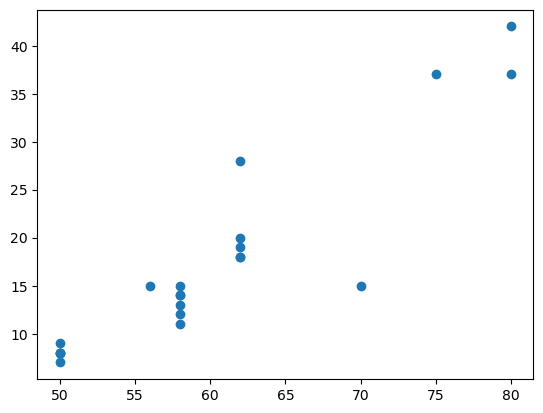

In [47]:
plt.scatter(df.AirFlow,df.StackLoss)

In [48]:

df = pd.read_excel('CDAC_DataBook.xlsx', sheet_name = 'stackloss')


# Split for train-test
x_train, x_test, y_train, y_test = train_test_split(df.drop('StackLoss', axis=1),df.StackLoss, test_size=0.1, random_state=20)

# Add constant term
x_train = sm.add_constant(x_train, prepend=False)
x_test = sm.add_constant(x_test, prepend=False)

# Prepare the model
mod1 = sm.OLS(y_train,x_train).fit()

print(mod1.summary())

                            OLS Regression Results                            
Dep. Variable:              StackLoss   R-squared:                       0.908
Model:                            OLS   Adj. R-squared:                  0.888
Method:                 Least Squares   F-statistic:                     46.11
Date:                Thu, 04 Jun 2026   Prob (F-statistic):           1.67e-07
Time:                        09:31:50   Log-Likelihood:                -45.877
No. Observations:                  18   AIC:                             99.75
Df Residuals:                      14   BIC:                             103.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
AirFlow        0.7001      0.152      4.592      0.0

#### **Day 1: Fundamentals of Simple Linear Regression**
1. **The Core Equation**
    - The foundation of simple linear regression is the equation of a straight line:
    - y = mx + c
    - Where 'y' is the response variable, 'x' is the predictor variable, 'm' is the coefficient (slope), and 'c' is the intercept/constant.


2. **Model Training with Statsmodels (Geyser Dataset)**
    - When using libraries like Statsmodels (OLS), an intercept is not included by default. We must manually add a constant term (a column of 1.0s) to the predictor matrix before fitting the model.
    - Example Equation Extracted from Model:
eruption = (0.0782 × waiting) - 2.08

    - Interpretation: For every 1 unit increase in waiting time, the eruption duration increases by 0.0782 units. The intercept is -2.08.

3. **Model Evaluation Metrics**
    - R-Squared (Coefficient of Determination): Evaluated at 0.804 for the Geyser dataset. This signifies that 80.4% of the variance in the response variable (eruptions) is explained by our model.
    - **Variance & ANOVA Concept:** 
        - Total Variance = Explained Variance + Unexplained Variance
        - The goal of the model is to maximize Explained Variance and minimize Unexplained Variance. The F-statistic is derived from the ratio of Explained to Unexplained variance.
        - Residuals: In regression terminology, 'Errors' (the difference between predicted values and actual values) are formally called 'Residuals'.
